##Project 1:
####Group: Sean Feeny, Shota Muraishi
  

####Assignment:
You are to model the data using logistic regression to predict if an individual is covid positive or negative. Be sure to complete the following items in your analysis.

Discuss the importance of the data set to society, and why it is important to have an inferential perspective on this data set not just a predictive viewpoint. In particular state why it is important to understand the inputs and if they affect the output.

Briefly discuss how to had to clean your data set, and issues with the data set in the raw form. (Data preprocessing)

Explain how you are going to prevent overfitting of your data set. Are you going to split your data set, use penalized metrics, or some combination of both?

Investigate your data set graphically and include a few relevant graphs for predicting your output. Form your first logistics regression model  with main effects (only) based on these graphs.

Create a derived variable which is the number of existing conditions of astma, immunosupression, diabetes, pneumonia. Feel free to modify this derived variable and research what a derived variable is. Add this derived variable to your logistic regression model. Did it improve the model?

State what variables are statistically significant in your model. Calculate the odds ratio and explain it's meaning.

Consider adding 1-3 interaction terms to your model. Did it improve the model?
Use lasso logistic regression to select your model (and variables).

Determine if a different cutoff value for probability will increase the model accuracy based on the ROC curves for your model. Would you rather have a higher recall or precision? Explain what each would mean in a practical context of this data.

For your final model calculate accuracy, precision, recall, explain if variables are significant and importance with the odds ratio. Explain what all these things mean in a practical way. What is your best model? How predictive is it, and what inputs affect the output. What conclusions would you give to the general public and a doctor?


1. Discuss the importance of the data set to society, and why it is important to have an inferential perspective on this data set not just a predictive viewpoint. In particular state why it is important to understand the inputs and if they affect the output.

- This model gives Covid data from Mexico, and could be very useful for predicting Covid or maybe other similar diseases. It is important to have an inferential perspective because that will help us figure out why certain things are correlated with Covid. In the case of some of the things variables like asthma, they are inversely related to Covid outcomes, so it can be important to figure out why. Perhaps these people are more likely to have similar symptoms to Covid, meaning they are more likely to take a Covid test while not having the virus.

In [ ]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score
from re import X
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression



In [ ]:
#getting the file
uploaded = files.upload()

Saving patient (2).csv to patient (2).csv


In [ ]:
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  df = pd.read_csv(fn)

display(df.head())

User uploaded file "archive (2).zip" with length 539124 bytes


,sex,patient_type,intubated,pneumonia,age,pregnant,diabetes,copd,asthma,immunosuppression,hypertension,other_diseases,cardiovascular,obesity,chronic_kidney_failure,smoker,another_case,outcome,icu,death_date
0,2,1,97,2,42,97,2,2,1,2,2,2,2,2,2,2,99,1,97,9999-99-99
1,1,1,97,2,51,2,2,2,2,2,2,2,2,2,2,2,99,1,97,9999-99-99
2,2,2,2,2,51,97,1,2,2,2,1,2,2,1,2,2,99,1,2,9999-99-99
3,2,2,2,2,57,97,1,2,2,2,2,2,2,2,2,2,99,1,2,2020-04-01
4,1,2,2,2,44,2,1,2,2,2,2,2,2,2,2,2,2,2,2,9999-99-99


In [ ]:
#view overall distributions of outcome
df['outcome'] = df['outcome'].replace({1: 'POSITIVE', 2: 'NEGATIVE', 3: np.nan})
display(df['outcome'].value_counts())
df['outcome_coded'] = df['outcome'].map({'POSITIVE': 1, 'NEGATIVE': 0})


,count
outcome,
NEGATIVE,59704
POSITIVE,23471


Cleaning the data:

In [ ]:
#replace 97-99 values with null values (assuming ages do not have any missing values) and converting to 0 and 1 instead of 1 and 2
for entry in df:
  if entry != 'age':
    df[entry] = df[entry].replace({2: 0, 97: np.nan, 98: np.nan, 99: np.nan})
#go through death_date column, replacing '9999-99-99' with 0 and anything else with 1
df['death_date'] = df['death_date'].replace({'9999-99-99': 0})
for i in range(len(df['death_date'])):
  if df['death_date'][i] != 0:
    df['death_date'][i] = 1
df['outcome_coded'] = df['outcome'].map({'POSITIVE': 1, 'NEGATIVE': 0})
#copy death date column into death column then drop death date
df['death'] = df['death_date']
df = df.drop(columns=['death_date'])


In [ ]:
#count positives in death column
print(df['death'].value_counts())

death
0    92404
1     3435
Name: count, dtype: int64


In [ ]:
display(df.head())

display(df.isnull().sum())

,sex,patient_type,intubated,pneumonia,age,pregnant,diabetes,copd,asthma,immunosuppression,...,other_diseases,cardiovascular,obesity,chronic_kidney_failure,smoker,another_case,outcome,icu,outcome_coded,death
0,0,1,NaN,0.0,42,NaN,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,POSITIVE,NaN,1.0,0
1,1,1,NaN,0.0,51,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,POSITIVE,NaN,1.0,0
2,0,0,0.0,0.0,51,NaN,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,NaN,POSITIVE,0.0,1.0,0
3,0,0,0.0,0.0,57,NaN,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,POSITIVE,0.0,1.0,1
4,1,0,0.0,0.0,44,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NEGATIVE,0.0,0.0,0


,0
sex,0
patient_type,0
intubated,70292
pneumonia,8
age,0
pregnant,48952
diabetes,417
copd,404
asthma,409
immunosuppression,426


In [ ]:
#Assign all values of pregnancy to no for males
df.loc[df['sex'] == 0, 'pregnant'] = 0
#print the number of missing values for pregnancy
print('Missing values of pregnancy for women:', df['pregnant'].isnull().sum())

Missing values of pregnancy for women: 232


2. Briefly discuss how you had to clean your data set, and issues with the data set in the raw form. (Data preprocessing)
- In its raw form, the data uses 97, 98, and 99 to indicate missing data, so we converted those to null values (except in the age column)

- As shown in the table above, there are several columns with large numbers of missing values. Since we are trying to predict outcome, we of course had to drop the 12000 rows with missing outcome values.

- One of these columns with a lot of missing data is also pregnancy, which gives missing values for all males (about half the rows), so we converted all males to having a value of 0 for pregnancy. This left only 232 females with missing values for pregnancy
- Two other of these columns are icu and intubated, with about 70000 missing values each, so we decided to drop them both.
- We were unable to find out what patient type meant, so we decided to drop that one as well, since we have no way to interpret this data.
- We also assumed that if there was not a valid death date, the person had died, so we made a new column to see if the person had died

3. Explain how you are going to prevent overfitting of your data set. Are you going to split your data set, use penalized metrics, or some combination of both?

- We decided to prevent overfitting by splitting the data into training and testing and also using Lasso regression to figure out which variables are not important.
- We also decided to use AIC and BIC to test the logistic regression models with a penalized metric


4. Investigate your data set graphically and include a few relevant graphs for predicting your output. Form your first logistics regression model with main effects (only) based on these graphs.
- We used the following code (currently commented out because it produces a very long list of graphs) for a single variable model for each variable to figure out which inputs affect the output.
- Based on the p values, COPD and chronic kidney failure did not affect the outcome, so we decided to drop these columns.
- Another case had a p value of 0.034, which is one of the higher ones. There are also 35000 missing values for another case, so we decided to drop this column as well

In [ ]:
threshold = 0.28   #This was the optimal threshold for the main effects model that we found later using the ROC curve

In [ ]:
# #optimal threshold to be used for probabilities
# for column in df:

#   if column != 'outcome_coded' and column != 'outcome':
#     #for each column, temporarily ignore null values
#     #create a training and testing set
#     X = df[[column, 'outcome_coded']].dropna()
#     y = X['outcome_coded']
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#     logistic_column = smf.logit(formula='outcome_coded ~ '+ column, data=X_train).fit()
#     print(logistic_column.summary())
#     # Calculate the conditional probability
#     conditional_prob = df.groupby(column)['outcome'].apply(lambda x: (x == 'POSITIVE').mean())
#     #find the accuracy, precision, recall from the training data
#     y_pred = logistic_column.predict(X_train)
#     y_pred = np.where(y_pred > threshold, 1, 0)
#     print("Training Accuracy:", accuracy_score(y_train, y_pred))
#     print("Training Precision:", precision_score(y_train, y_pred))
#     print("Training Recall:", recall_score(y_train, y_pred))
#     #find the accuracy, precision, recall from the test data
#     y_pred = logistic_column.predict(X_test)
#     y_pred = np.where(y_pred > threshold, 1, 0)
#     print("Test Accuracy:", accuracy_score(y_test, y_pred))
#     print("Test Precision:", precision_score(y_test, y_pred))
#     print("Test Recall:", recall_score(y_test, y_pred))

#     # Create a bar plot
#     plt.figure(figsize=(8, 6))
#     conditional_prob.plot(kind='bar', color=['skyblue', 'salmon'])
#     plt.title('Conditional Probability of Positive Outcome by '+column)
#     plt.xlabel(column)
#     plt.ylabel('Probability of Positive Outcome')
#     plt.xticks(rotation=0)
#     plt.ylim(0, 1)
#     plt.grid(axis='y')
#     plt.show()

In [ ]:
#create a new data frame that drops intubated, copd, chronic kidney failure, another case, patient type, and death date columns
df_new = df.drop(columns=['intubated', 'icu', 'copd', 'chronic_kidney_failure', 'another_case', 'patient_type', 'outcome', 'outcome_coded'])
#give the shape of df_new
print('Shape of table before removing non-outcome missing values:',df_new.shape)
#display(df_new.head())
#drop null values
df_new = df_new.dropna()
#give the shape of df_new
print('Shape of table after removing non-outcome missing values:',df_new.shape)
df_new = df.drop(columns=['intubated','icu', 'copd', 'chronic_kidney_failure', 'another_case', 'patient_type', 'outcome'])
df_new = df_new.dropna()
#give the shape of df_new
print('Shape of table after removing outcome missing values:',df_new.shape)


Shape of table before removing non-outcome missing values: (95839, 13)
Shape of table after removing non-outcome missing values: (94885, 13)
Shape of table after removing outcome missing values: (82385, 14)



As shown in the code above, we get only about 1000 rows with missing values (other than outcome, which we have to drop) after removing those columns that we decided to drop, so we felt that this was a small enough number that dropping any remaining rows with a missing value was reasonable.

In [ ]:
#create a main effects model for df_new for the columns we did not drop
# Split the data into training and testing sets
X = df_new
y = df_new['outcome_coded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
logistic_main = smf.logit(formula='outcome_coded ~ sex + pneumonia + age + pregnant + diabetes + asthma + immunosuppression + hypertension + other_diseases + cardiovascular + obesity + smoker + death', data=X_train).fit()
print(logistic_main.summary())
#test the model on the training data
y_pred = logistic_main.predict(X_train)
y_pred = np.where(y_pred > threshold, 1, 0)
#give the accuracy, precision, and recall
print("Training Accuracy:", accuracy_score(y_train, y_pred))
print("Training Precision:", precision_score(y_train, y_pred))
print("Training Recall:", recall_score(y_train, y_pred))
#find the accuracy, precision, recall from the test data
y_pred = logistic_main.predict(X_test)
y_pred = np.where(y_pred > threshold, 1, 0)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
aic_result = logistic_main.aic
bic_result = logistic_main.bic

print(f"AIC for the model: {aic_result}")
print(f"BIC for the model: {bic_result}")

Optimization terminated successfully.
         Current function value: 0.552042
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          outcome_coded   No. Observations:                65908
Model:                          Logit   Df Residuals:                    65894
Method:                           MLE   Df Model:                           13
Date:                Fri, 10 Oct 2025   Pseudo R-squ.:                 0.07060
Time:                        23:57:24   Log-Likelihood:                -36384.
converged:                       True   LL-Null:                       -39148.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.6481      0.027    -60.144      0.000      -1.702      -1.594
death[T.

5. Create a derived variable which is the number of existing conditions of astma, immunosupression, diabetes, pneumonia. Feel free to modify this derived variable and research what a derived variable is. Add this derived variable to your logistic regression model. Did it improve the model?

- After experimenting with different derived variables (including the listed ones as well as one that included all conditions), the most effective way we found was by creating a derived variable of diabetes, pneumonia, and obesity. We chose these because they were the only ones positively correlated with outcome, while the other variables were negatively correlated.

In [ ]:
derived_variable =  df_new['diabetes'] + df_new['pneumonia']+ df_new['obesity']
threshold = 0.36 #this is the optimal cutoff found later for with the ROC curve with the derived variable model
#add derived variables to df_derived
df_derived = df_new[['age', 'sex', 'death', 'outcome_coded', 'immunosuppression', 'asthma', 'cardiovascular','smoker','other_diseases','pregnant']]
df_derived['derived_variable'] = derived_variable
display(df_derived.head())

,age,sex,death,outcome_coded,immunosuppression,asthma,cardiovascular,smoker,other_diseases,pregnant,derived_variable
0,42,0,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,51,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,51,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,57,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,44,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


The main effects model with the derived variable is shown below:

In [ ]:
#create a training and testing set
X = df_derived
y = df_derived['outcome_coded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

logistic_derived_variable = smf.logit(formula='outcome_coded ~ derived_variable + sex + death + smoker + immunosuppression + asthma + cardiovascular + other_diseases + age + pregnant', data=X_train).fit()
print(logistic_derived_variable.summary())
#calculate precision, recall, accuracy on training data
y_pred = logistic_derived_variable.predict(X_train)
y_pred = np.where(y_pred > threshold, 1, 0)
print("Training Accuracy:", accuracy_score(y_train, y_pred))
print("Training Precision:", precision_score(y_train, y_pred))
print("Training Recall:", recall_score(y_train, y_pred))
#calculate precision, recall, accuracy on test data
y_pred = logistic_derived_variable.predict(X_test)
y_pred = np.where(y_pred > threshold, 1, 0)
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Testing Precision:", precision_score(y_test, y_pred))
print("Testing Recall:", recall_score(y_test, y_pred))
aic_result = logistic_derived_variable.aic
bic_result = logistic_derived_variable.bic

print(f"AIC for the model: {aic_result}")
print(f"BIC for the model: {bic_result}")

Optimization terminated successfully.
         Current function value: 0.554493
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          outcome_coded   No. Observations:                65908
Model:                          Logit   Df Residuals:                    65897
Method:                           MLE   Df Model:                           10
Date:                Fri, 10 Oct 2025   Pseudo R-squ.:                 0.06461
Time:                        23:48:51   Log-Likelihood:                -36546.
converged:                       True   LL-Null:                       -39070.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.5546      0.027    -58.633      0.000      -1.607      -1.503
death[T.

The model below with just the derived variable, sex, and death is slightly better with an accuracy of 0.72:

In [ ]:
#model with just derived variable, sex, and death
#create a training and testing set
X = df_derived
y = df_derived['outcome_coded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

logistic_derived_variable = smf.logit(formula='outcome_coded ~ derived_variable + sex + death', data=X_train).fit()
print(logistic_derived_variable.summary())
#calculate precision, recall, accuracy on training data
y_pred = logistic_derived_variable.predict(X_train)
y_pred = np.where(y_pred > threshold, 1, 0)
print("Training Accuracy:", accuracy_score(y_train, y_pred))
print("Training Precision:", precision_score(y_train, y_pred))
print("Training Recall:", recall_score(y_train, y_pred))
#calculate precision, recall, accuracy on test data
y_pred = logistic_derived_variable.predict(X_test)
y_pred = np.where(y_pred > threshold, 1, 0)
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Testing Precision:", precision_score(y_test, y_pred))
print("Testing Recall:", recall_score(y_test, y_pred))
aic_result = logistic_derived_variable.aic
bic_result = logistic_derived_variable.bic

print(f"AIC for the model: {aic_result}")
print(f"BIC for the model: {bic_result}")

Optimization terminated successfully.
         Current function value: 0.563814
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          outcome_coded   No. Observations:                65908
Model:                          Logit   Df Residuals:                    65904
Method:                           MLE   Df Model:                            3
Date:                Fri, 10 Oct 2025   Pseudo R-squ.:                 0.04870
Time:                        23:49:39   Log-Likelihood:                -37160.
converged:                       True   LL-Null:                       -39062.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.0659      0.014    -76.857      0.000      -1.093      -1.039
death[T.1] 

6. State what variables are statistically significant in your model. Calculate the odds ratio and explain it's meaning.
- All the variables are statistically significant except COPD and Chronic kidney failure based on their p values.

- The odds ratios (given in the code below) give the change caused by increasing the value of that variable by 1. In the case of age, for example, the odds ratio is about 1.016, meaning the odds of a positive outcome is multiplied by about 1.016 for each additional year

In [ ]:
#calculate odds ratio
for column in logistic_main.params.index:
  if column != 'Intercept':
    odds_ratio_column = np.exp(logistic_main.params[column])
    print(f"Odds Ratio for {column}: {odds_ratio_column}")

Odds Ratio for death[T.1]: 2.9570407701428576
Odds Ratio for sex: 0.69136412798
Odds Ratio for pneumonia: 2.0364038511416998
Odds Ratio for age: 1.0167823991136804
Odds Ratio for pregnant: 0.8273575281047219
Odds Ratio for diabetes: 1.1685902387596427
Odds Ratio for asthma: 0.6690130200667239
Odds Ratio for immunosuppression: 0.5254231961179876
Odds Ratio for hypertension: 0.8750815562039811
Odds Ratio for other_diseases: 0.6470979450303237
Odds Ratio for cardiovascular: 0.491004740616097
Odds Ratio for obesity: 1.5368911771126315
Odds Ratio for smoker: 0.7316070689572257


7. Consider adding 1-3 interaction terms to your model. Did it improve the model?
- Since our best model so far is with just derived variable, death, and sex, we will try interaction terms between those:


In [ ]:
#interaction model with derived variable, sex, and death
#create a training and testing set
X = df_derived
y = df_derived['outcome_coded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

logistic_interaction = smf.logit(formula='outcome_coded ~ derived_variable + sex + death + sex:derived_variable', data=X_train).fit()
print(logistic_interaction.summary())
#calculate precision, recall, accuracy on training data
y_pred = logistic_interaction.predict(X_train)
y_pred = np.where(y_pred > threshold, 1, 0)
print("Training Accuracy:", accuracy_score(y_train, y_pred))
print("Training Precision:", precision_score(y_train, y_pred))
print("Training Recall:", recall_score(y_train, y_pred))
#calculate precision, recall, accuracy on test data
y_pred = logistic_interaction.predict(X_test)
y_pred = np.where(y_pred > threshold, 1, 0)
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Testing Precision:", precision_score(y_test, y_pred))
print("Testing Recall:", recall_score(y_test, y_pred))
aic_result = logistic_interaction.aic
bic_result = logistic_interaction.bic

print(f"AIC for the model: {aic_result}")
print(f"BIC for the model: {bic_result}")

Optimization terminated successfully.
         Current function value: 0.563792
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          outcome_coded   No. Observations:                65908
Model:                          Logit   Df Residuals:                    65903
Method:                           MLE   Df Model:                            4
Date:                Fri, 10 Oct 2025   Pseudo R-squ.:                 0.04867
Time:                        23:49:58   Log-Likelihood:                -37158.
converged:                       True   LL-Null:                       -39059.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -1.1061      0.015    -71.856      0.000      -1.136      -1.076

After testing interaction terms between each of the 3 variables above, none gave a model that was better than if the interaction term was not included.

8. Use lasso logistic regression to select your model (and variables).


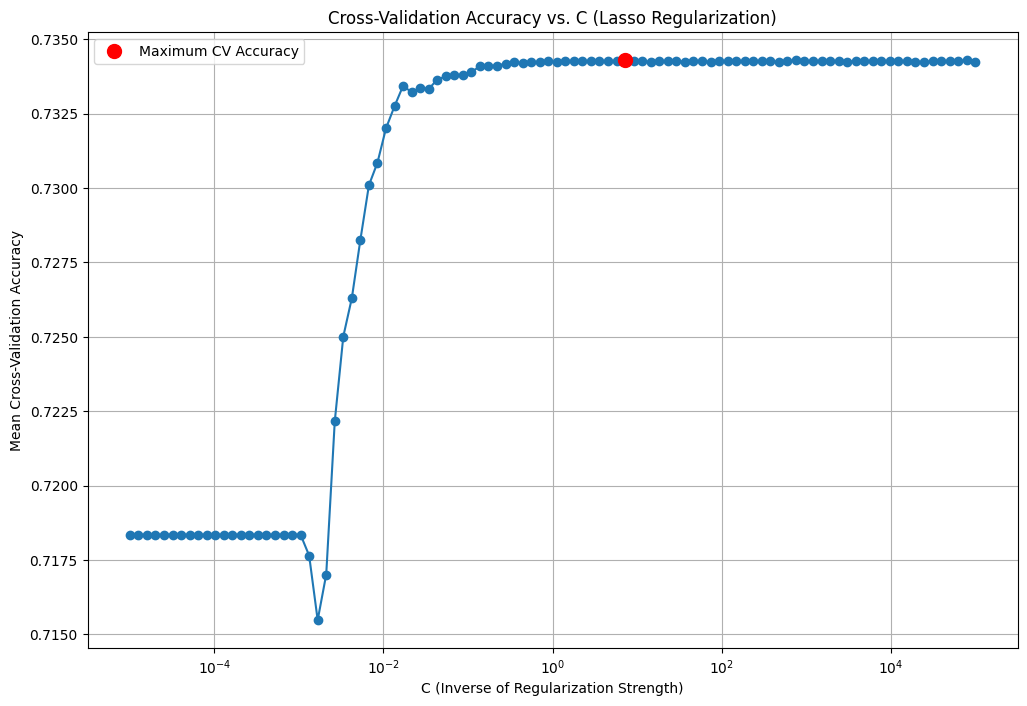


Optimal C value based on maximum cross-validation accuracy: 7.2208


In [ ]:
#lasso regression

# Separate features (X) and target (y)
X = df_new.drop('outcome_coded', axis=1)
y = df_new['outcome_coded']

# Split data into training and testing sets for initial evaluation (though cross-validation is used for model selection)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Standardize features
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X) # Scale the full dataset for cross-validation
X_scaled = X_train

# Perform Logistic Regression with L1 penalty for different values of C and calculate cross-validation scores
cv_scores = []
params = []
weights = [] # Initialize a list to store coefficients
# Use a wider range for C
C_range = np.logspace(-5, 5, 100) # Use logspace for better visualization across orders of magnitude

for c in C_range:
    # Use penalty='l1' for Lasso regularization and solver='liblinear' or 'saga' which support l1
    lr = LogisticRegression(C=c, penalty='l1', solver='liblinear', multi_class='ovr', max_iter=1000)

    # Calculate cross-validation score (e.g., using 5 folds)
    # Using the scaled full dataset for cross_val_score
    scores = cross_val_score(lr, X_scaled, y_train, cv=5)
    cv_scores.append(np.mean(scores))

    # Train the model on the full scaled data to get coefficients for plotting
    lr.fit(X_scaled, y_train)
    weights.append(lr.coef_[0]) # Store the coefficients

    params.append(c)

# Convert weights to a numpy array for easier plotting
weights = np.array(weights)

# Plotting the cross-validation scores as a function of C
plt.figure(figsize=(12, 8))
plt.plot(params, cv_scores, marker='o')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.xlabel('C (Inverse of Regularization Strength)')
plt.title('Cross-Validation Accuracy vs. C (Lasso Regularization)')
plt.xscale('log')
plt.grid(True)

# Highlight the maximum CV score point
max_cv_index = np.argmax(cv_scores)
plt.plot(params[max_cv_index], cv_scores[max_cv_index], 'ro', markersize=10, label='Maximum CV Accuracy')

plt.legend()
plt.show()

# Print the C value with the maximum cross-validation score
optimal_c = params[max_cv_index]
print(f"\nOptimal C value based on maximum cross-validation accuracy: {optimal_c:.4f}")


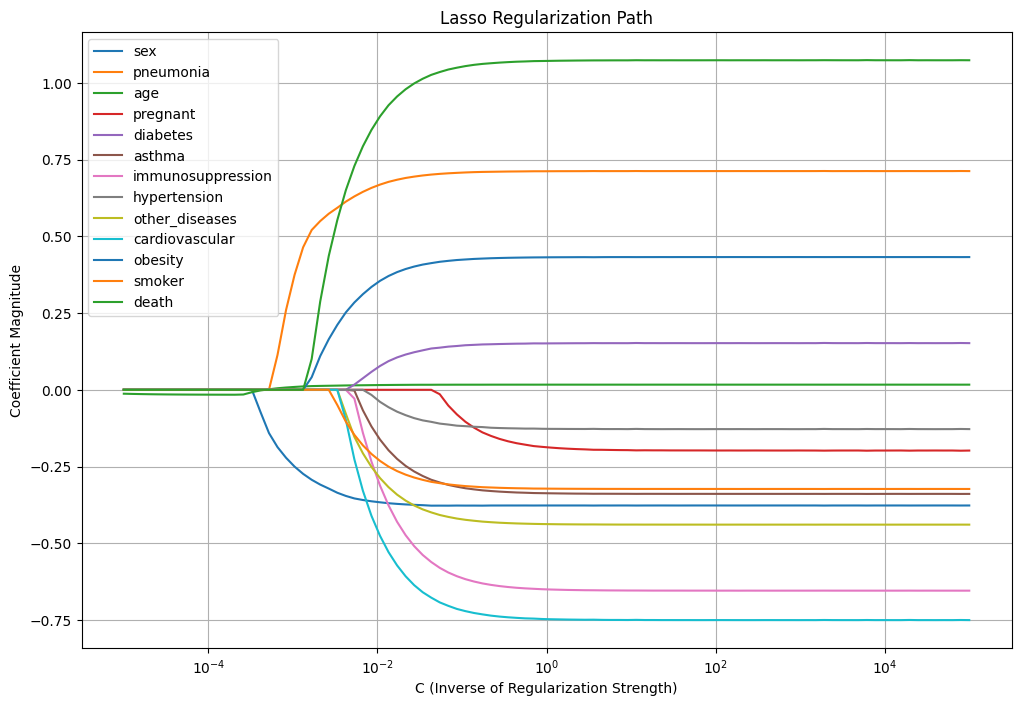

In [ ]:
# Plotting the coefficients as a function of C
plt.figure(figsize=(12, 8))

# Plot coefficients for a few selected features to avoid clutter
# You can change the indices to plot different features
# Let's select a few features that had non-zero coefficients for the optimal C
selected_feature_names_to_plot = X
selected_features_indices_to_plot = [X_train.columns.get_loc(col) for col in selected_feature_names_to_plot]


for i, feature_index in enumerate(selected_features_indices_to_plot):
    plt.plot(params, weights[:, feature_index], label=X_train.columns[feature_index])


plt.ylabel('Coefficient Magnitude')
plt.xlabel('C (Inverse of Regularization Strength)')
plt.title('Lasso Regularization Path')
plt.legend()
plt.xscale('log')
plt.grid(True)
plt.show()

In [ ]:
# Train a Logistic Regression model with the optimal C value
# Assume optimal_c, X_scaled, and y are available from previous cells

lr_optimal = LogisticRegression(C= optimal_c
                                , penalty='l1', solver='liblinear', multi_class='ovr', max_iter=1000)
lr_optimal.fit(X_scaled, y_train)

# Print the coefficients
print("Lasso Logistic Regression Coefficients for optimal C:")
for feature, coef in zip(X.columns, lr_optimal.coef_[0]):
    print(f"{feature}: {coef:.4f}")

Lasso Logistic Regression Coefficients for optimal C:
sex: -0.3772
pneumonia: 0.7127
age: 0.0167
pregnant: -0.1970
diabetes: 0.1525
asthma: -0.3391
immunosuppression: -0.6541
hypertension: -0.1275
other_diseases: -0.4392
cardiovascular: -0.7496
obesity: 0.4325
smoker: -0.3230
death: 1.0741


In [ ]:
# Make predictions on the test set
y_pred = lr_optimal.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


Accuracy: 0.7417
Precision: 0.6055
Recall: 0.1664


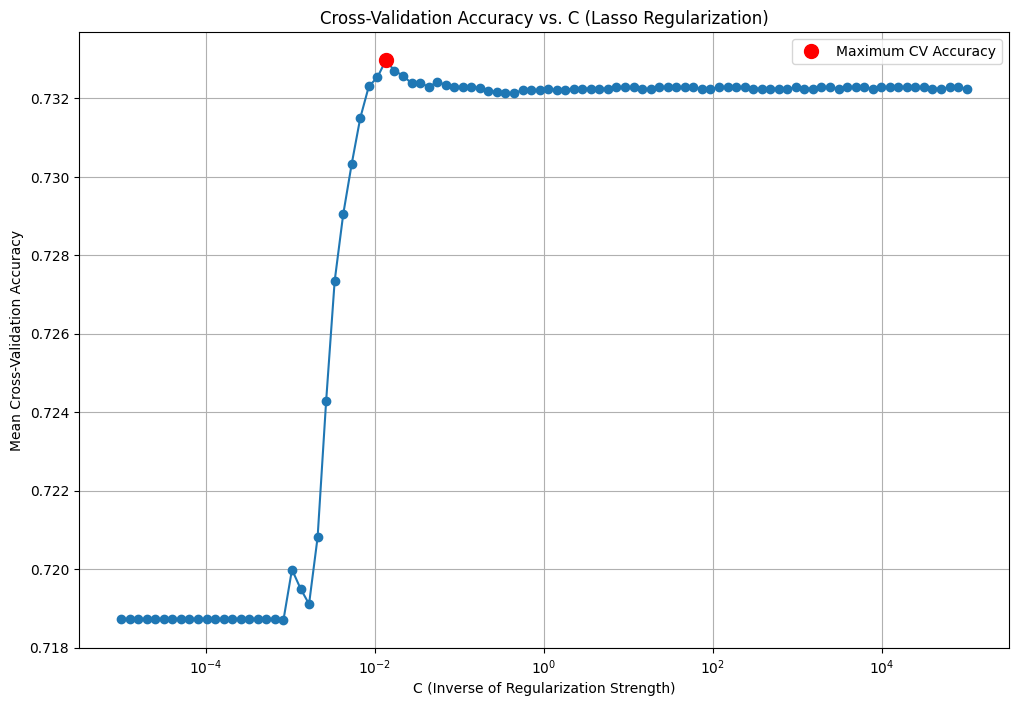


Optimal C value based on maximum cross-validation accuracy: 0.0135


In [ ]:
#lasso regression using the derived variable instead of its components

# Separate features (X) and target (y)
X = df_derived.drop('outcome_coded', axis=1)
y = df_derived['outcome_coded']

# Split data into training and testing sets for initial evaluation (though cross-validation is used for model selection)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Standardize features
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X) # Scale the full dataset for cross-validation
X_scaled = X_train

# Perform Logistic Regression with L1 penalty for different values of C and calculate cross-validation scores
cv_scores = []
params = []
weights = [] # Initialize a list to store coefficients
# Use a wider range for C
C_range = np.logspace(-5, 5, 100) # Use logspace for better visualization across orders of magnitude

for c in C_range:
    # Use penalty='l1' for Lasso regularization and solver='liblinear' or 'saga' which support l1
    lr = LogisticRegression(C=c, penalty='l1', solver='liblinear', multi_class='ovr', max_iter=1000)

    # Calculate cross-validation score (e.g., using 5 folds)
    # Using the scaled full dataset for cross_val_score
    scores = cross_val_score(lr, X_scaled, y_train, cv=5)
    cv_scores.append(np.mean(scores))

    # Train the model on the full scaled data to get coefficients for plotting
    lr.fit(X_scaled, y_train)
    weights.append(lr.coef_[0]) # Store the coefficients

    params.append(c)

# Convert weights to a numpy array for easier plotting
weights = np.array(weights)

# Plotting the cross-validation scores as a function of C
plt.figure(figsize=(12, 8))
plt.plot(params, cv_scores, marker='o')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.xlabel('C (Inverse of Regularization Strength)')
plt.title('Cross-Validation Accuracy vs. C (Lasso Regularization)')
plt.xscale('log')
plt.grid(True)

# Highlight the maximum CV score point
max_cv_index = np.argmax(cv_scores)
plt.plot(params[max_cv_index], cv_scores[max_cv_index], 'ro', markersize=10, label='Maximum CV Accuracy')

plt.legend()
plt.show()

# Print the C value with the maximum cross-validation score
optimal_c = params[max_cv_index]
print(f"\nOptimal C value based on maximum cross-validation accuracy: {optimal_c:.4f}")


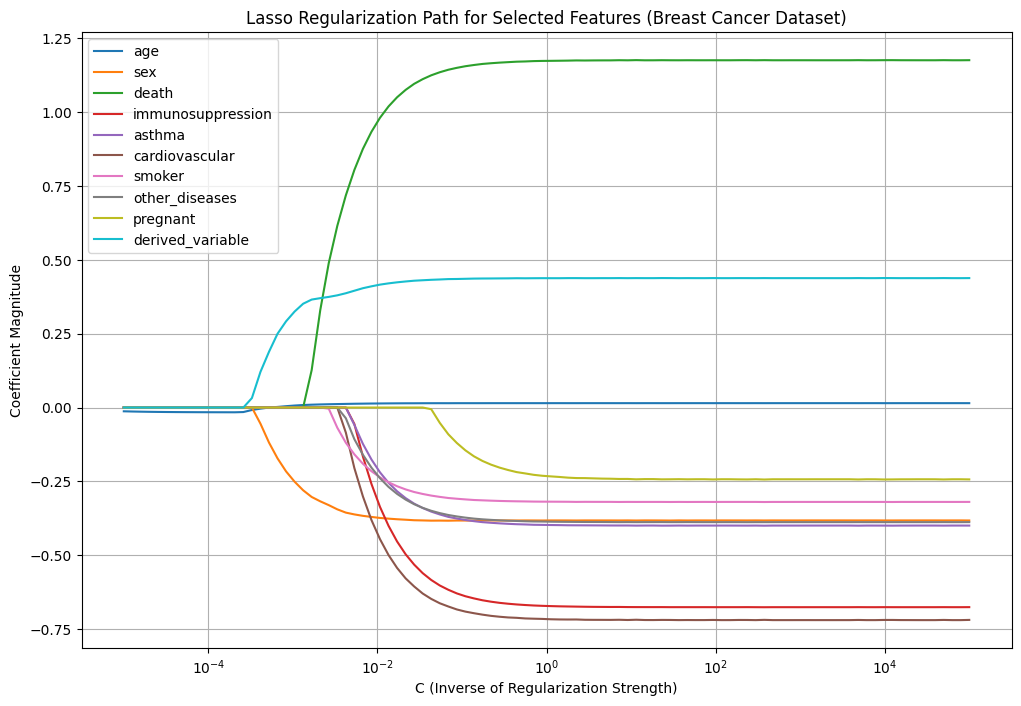

In [ ]:
# Plotting the coefficients as a function of C
plt.figure(figsize=(12, 8))

# Plot coefficients for a few selected features to avoid clutter
# You can change the indices to plot different features
# Let's select a few features that had non-zero coefficients for the optimal C
selected_feature_names_to_plot = X
selected_features_indices_to_plot = [X_train.columns.get_loc(col) for col in selected_feature_names_to_plot]


for i, feature_index in enumerate(selected_features_indices_to_plot):
    plt.plot(params, weights[:, feature_index], label=X_train.columns[feature_index])


plt.ylabel('Coefficient Magnitude')
plt.xlabel('C (Inverse of Regularization Strength)')
plt.title('Lasso Regularization Path')
plt.legend()
plt.xscale('log')
plt.grid(True)
plt.show()

In [ ]:
# Train a Logistic Regression model with the optimal C value
# Assume optimal_c, X_scaled, and y are available from previous cells

lr_optimal = LogisticRegression(C= optimal_c
                                , penalty='l1', solver='liblinear', multi_class='ovr', max_iter=1000)
lr_optimal.fit(X_scaled, y_train)

# Print the coefficients
print("Lasso Logistic Regression Coefficients (with derived variable) for optimal C:")
for feature, coef in zip(X.columns, lr_optimal.coef_[0]):
    print(f"{feature}: {coef:.4f}")

Lasso Logistic Regression Coefficients for optimal C:
age: 0.0140
sex: -0.3761
death: 1.0193
immunosuppression: -0.4005
asthma: -0.2547
cardiovascular: -0.4998
smoker: -0.2530
other_diseases: -0.2687
pregnant: 0.0000
derived_variable: 0.4203


In [ ]:
# Make predictions on the test set
y_pred = lr_optimal.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


Accuracy: 0.7357
Precision: 0.5918
Recall: 0.1334


Using lasso regression above on the model with the derived variable, the coefficient of pregnant is 0. That is because of pregnant is highly correlated with sex.

We got higher accuracy (compared to the main effects model) for lasso regression both with and without the derived variable. But the recall of either lasso regression is smaller than either logistic regression.

9. Determine if a different cutoff value for probability will increase the model accuracy based on the ROC curves for your model. Would you rather have a higher recall or precision? Explain what each would mean in a practical context of this data.

AUC: 0.6781
Optimal Cutoff Probability (Youden's J): 0.2736
Accuracy: 0.6542


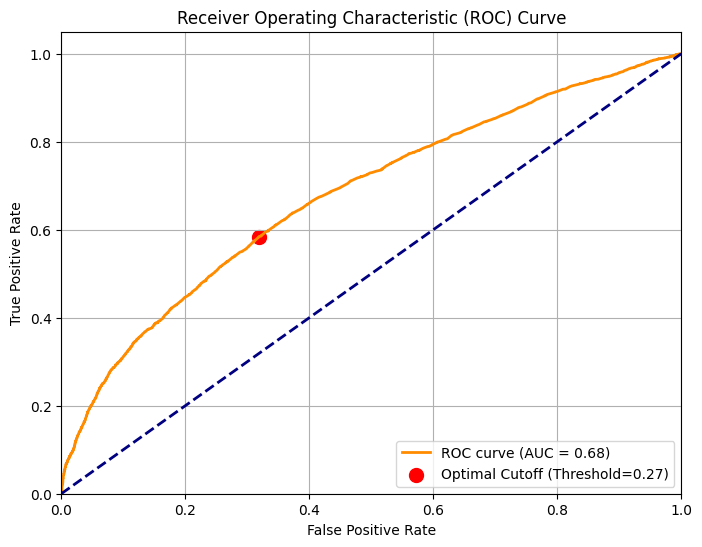

In [ ]:
# ROC curve for main effect model
X = df_new.drop('outcome_coded', axis=1)
y = df_new['outcome_coded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, logistic_main.predict(X_test))

# Calculate the Area Under the ROC Curve (AUC)
roc_auc = roc_auc_score(y_test, logistic_main.predict(X_test))

# Find the optimal cutoff probability (maximizing Youden's J statistic)
# Youden's J = Sensitivity + Specificity - 1
# Sensitivity = TPR
# Specificity = 1 - FPR
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"AUC: {roc_auc:.4f}")
print(f"Optimal Cutoff Probability (Youden's J): {optimal_threshold:.4f}")


# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Plot random guess line
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', s=100, label=f'Optimal Cutoff (Threshold={optimal_threshold:.2f})') # Mark optimal cutoff

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)


predicted_classes = (logistic_main.predict(X_test) > optimal_threshold).astype(int)
# Calculate Accuracy
accuracy = accuracy_score(y_test, predicted_classes)
print(f"Accuracy: {accuracy:.4f}")

AUC: 0.6315
Optimal Cutoff Probability (Youden's J): 0.3597
Accuracy: 0.7281


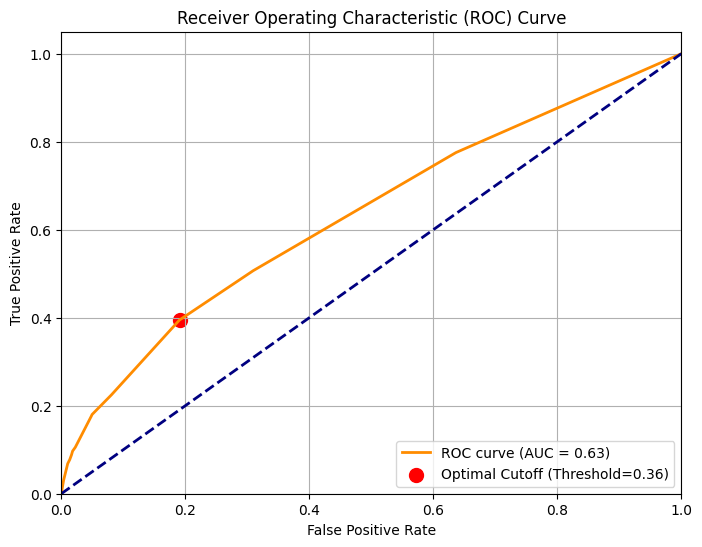

In [ ]:
# ROC curve for model includes derived variable
X = df_derived.drop('outcome_coded', axis=1)
y = df_derived['outcome_coded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, logistic_derived_variable.predict(X_test))

# Calculate the Area Under the ROC Curve (AUC)
roc_auc = roc_auc_score(y_test, logistic_derived_variable.predict(X_test))

# Find the optimal cutoff probability (maximizing Youden's J statistic)
# Youden's J = Sensitivity + Specificity - 1
# Sensitivity = TPR
# Specificity = 1 - FPR
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"AUC: {roc_auc:.4f}")
print(f"Optimal Cutoff Probability (Youden's J): {optimal_threshold:.4f}")


# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Plot random guess line
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', s=100, label=f'Optimal Cutoff (Threshold={optimal_threshold:.2f})') # Mark optimal cutoff

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)


predicted_classes = (logistic_derived_variable.predict(X_test) > optimal_threshold).astype(int)
# Calculate Accuracy
accuracy = accuracy_score(y_test, predicted_classes)
print(f"Accuracy: {accuracy:.4f}")

- Using ROC curves for the main effects and derived variable models, we found thresholds of 0.28 and 0.36, respectively, which we used for those models in the above sections.
- For our initial tests, we had used 0.5 as the cutoff, but this ended up returning almost all negatives, resulting in a precision and recall at or very close to 0. The accuracy in these cases was about 72%, which is the fraction of the sample that is Covid negative, so this accuracy score was meaningless if it just assigns everything as negative. Adjusting the cutoff to the optimal cutoff gave lower accuracy but gave nonzero recall and precision, meaning the model is able to make actual predictions.
- In the case of something like Covid data, recall is probably a little more important to prioritize than precision. Having a low recall on Covid predictions means there would be a lot of people going around without knowing they have it, which could possibly increase spread or prevent them from getting treatment. Low precision in this case would mean that the model predicts a lot more people to have Covid than actually have it. This would be an inconvenience, but would lower spread.

10. For your final model calculate accuracy, precision, recall, explain if variables are significant and importance with the odds ratio. Explain what all these things mean in a practical way. What is your best model? How predictive is it, and what inputs affect the output. What conclusions would you give to the general public and a doctor?

- Our models with the best accuracy were both Lasso regression models and the logistic regression model with derived variable, death, and sex. Thes all had accuracies around 72-74%, but had low recalls in the range of around 13% to 20%.
- The main effects model with cutoff of 0.28 had a lower accuracy of around 65%, but had a much higher recall with around 55%.
- As far as AIC and BIC, there is not a major difference between the different models we used it on, but the main effects model had slightly lower values of around 72000 compared to the values around 74000 from the derived variable models.
- If we follow what we decided in question 9 and assume that recall is more important for this kind of data, then the main effects model is probably our best one. The AIC and BIC values also support this over the derived variable model.
- All of the variables included in our main effects model affect the output (since we dropped those columns that didn't), but the least impactful seems to be pregnancy because it is correlated with sex. Several variables indicate a lower chance of being Covid positive, such as asthma, pregnancy, being female, immunosuppression, hypertension, cardiovascular, other diseases, or being a smoker. Others indicate a higher chance, such as death, pneumonia, higher age, diabetes, and obesity. The strongest indicators in the two directions are death (odds ratio of 2.9), pneumonia (odds ratio of 2), cardiovascular (odds ratio of 0.49), and immunosuppression (odds ratio of 0.52).
- Since most of these variables are somewhat independent of Covid, we are not able to draw strong conclusions about most of them. Instead they will more likely impact the chances of someone taking a Covid test or experiencing symptoms due to asthma or another condition. However, both death and pneumonia can be caused by Covid and unsurprisingly, these are the two variables that are most strongly correlated with a positive outcome. Because so many of these variables, such as age, obesity, or sex, are not directly causally related to Covid, we can make no strong conclusions except perhaps that Covid causes death and pneumonia.